# Debug DPS SR On NLM

This notebook mirrors the NLM debug notebooks but tests Diffusion Posterior Sampling (DPS). It uses the same NLM unconditional HR checkpoint by default, creates a native LR measurement by artificial degradation, and records DPS measurement-loss and gradient diagnostics.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from omegaconf import OmegaConf

ROOT = Path("/projects/compures/nicolas/signal_sr")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from sr.data import build_dataloader
from sr.diagnostics import downsample_l1, rapsd_error
from sr.inference import Sampler
from sr.inference.inverter import freeze_for_inference
from sr.inference.sampler import measurement_loss
from sr.models import build_conditioner, build_denoiser, denoiser_conditioning_mode
from sr.objectives import Objective
from sr.schedules import build_noise_scheduler
from sr.schedules.spectral import dct2, dct_rapsd_from_coefficients
from sr.utils.checkpoints import load_model_weights
from sr.utils.config import load_config, merge_dict

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## User Settings

In [46]:
CONFIG_PATH = ROOT / "src/sr/configs/train/nlm_pixel_hr_linear_uncond.yaml"
CHECKPOINT_PATH = "/projects/compures/nicolas/signal_sr/runs/nlm_pixel_hr_linear_uncond/checkpoint-240000"
SPLIT = "val"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
SAMPLE_INDEX = 5
DEGRADE_MODE = "area"
MEASUREMENT_SPACE = "lr"
LOSS_TYPE = "l2_norm"
BASE_SAMPLER = "ddpm"
GUIDANCE_SCALE = 5.0
GUIDANCE_SCALES = [0.0, 0.5, 1.0, 2.0, 5.0, 8.0, 10.0]
RUN_GUIDANCE_SWEEP = True
RUN_SEED_SWEEP = False
SEEDS = [42, 43, 44]
MAX_DEBUG_STEPS = None  # Set to a small int for a quick trajectory smoke test.

DPS_DEFAULTS = {
    "base_sampler": BASE_SAMPLER,
    "guidance_scale": GUIDANCE_SCALE,
    "start_step": 0,
    "end_step": None,
    "clip_denoised": True,
    "loss": LOSS_TYPE,
}

torch.manual_seed(SEED)
device = torch.device(DEVICE)
cfg = load_config(CONFIG_PATH)
cfg.sampling.method = "dps"
cfg.sampling.dps = OmegaConf.create(DPS_DEFAULTS)
cfg.measurement = OmegaConf.create({"space": MEASUREMENT_SPACE, "downsample_mode": DEGRADE_MODE})
image_size = int(cfg.image_size)
lr_size = int(cfg.lr_size)
out_dir = ROOT / "outputs/dps_nlm_debug"
out_dir.mkdir(parents=True, exist_ok=True)
cfg

{'space': 'pixel',
 'seed': 42,
 'image_size': 128,
 'scale': 16,
 'lr_size': 8,
 'data': {'name': 'nlm',
  'root': '/projects/compures/datasets/NLM/crops',
  'split_dir': '/projects/compures/nicolas/signal_sr/data/nlm/splits/semi_biased/single/seed_2026',
  'image_size': 128,
  'scale': 8,
  'channels': 3,
  'split_strategy': 'train_hr_val_test_lr',
  'return_pair': False},
 'val_data': {'return_pair': True},
 'test_data': {'return_pair': True},
 'phase_defaults': {'train_file': 'train_pixel.py', 'infer_file': 'infer.py'},
 'denoiser': {'target': 'diffusers.UNet2DModel',
  'params': {'sample_size': 128,
   'in_channels': 3,
   'out_channels': 3,
   'layers_per_block': 2,
   'block_out_channels': [64, 128, 256, 256],
   'down_block_types': ['DownBlock2D',
    'DownBlock2D',
    'DownBlock2D',
    'AttnDownBlock2D'],
   'up_block_types': ['AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D', 'UpBlock2D'],
   'dropout': 0.1,
   'norm_num_groups': 32}},
 'objective': {'name': 'diffusion', 'predictio

## Load NLM HR Image And Build LR Measurement

In [47]:
data_cfg = merge_dict(cfg.data, cfg.get(f"{SPLIT}_data", {}))
data_cfg.return_pair = True
loader = build_dataloader(data_cfg, split=SPLIT, shuffle=False, batch_size=max(SAMPLE_INDEX + 1, 1))
batch = next(iter(loader))
batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

hr_pool = batch["hr"]
sample_idx = min(int(SAMPLE_INDEX), hr_pool.shape[0] - 1)
x_hr = hr_pool[sample_idx : sample_idx + 1]
y_lr = F.interpolate(x_hr, size=(lr_size, lr_size), mode=DEGRADE_MODE)
lr_up_ref = F.interpolate(y_lr, size=(image_size, image_size), mode="nearest")
debug_batch = dict(batch)
debug_batch.update({"image": lr_up_ref, "lr": y_lr, "lr_up": lr_up_ref, "hr": x_hr})

hr_pool.shape, y_lr.shape, lr_up_ref.shape, sample_idx

(torch.Size([6, 3, 128, 128]),
 torch.Size([1, 3, 8, 8]),
 torch.Size([1, 3, 128, 128]),
 5)

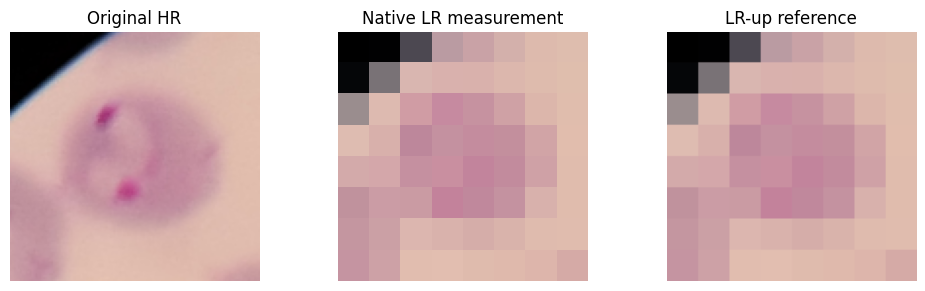

In [48]:
def image_for_plot(x, idx=0):
    img = x.detach().float().cpu()[idx]
    img = (img.clamp(-1, 1) + 1.0) / 2.0
    if img.shape[0] == 1:
        return img[0], "gray"
    return img.permute(1, 2, 0), None


def show_tensor(ax, x, title):
    img, cmap = image_for_plot(x)
    ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(10, 3))
show_tensor(axes[0], x_hr, "Original HR")
show_tensor(axes[1], y_lr, "Native LR measurement")
show_tensor(axes[2], lr_up_ref, "LR-up reference")
plt.tight_layout()

## Build Model, Scheduler, And DPS Sampler

In [49]:
noise_scheduler = build_noise_scheduler(cfg.noise_scheduler)
noise_scheduler.set_timesteps(cfg.noise_scheduler.n_infer_steps, device=device)
objective = Objective(cfg.objective, noise_scheduler)

checkpoint_path = Path(CHECKPOINT_PATH).expanduser() if CHECKPOINT_PATH else None
has_checkpoint = checkpoint_path is not None and checkpoint_path.exists()
if checkpoint_path is not None and not has_checkpoint:
    raise FileNotFoundError(f"CHECKPOINT_PATH does not exist: {checkpoint_path}")
if denoiser_conditioning_mode(cfg.denoiser) == "concat":
    raise ValueError("DPS debug notebook assumes no LR channel-concat conditioning.")

denoiser = build_denoiser(cfg.denoiser, data_channels=int(cfg.data.channels)).to(device)
conditioner = build_conditioner().to(device)
load_model_weights(str(checkpoint_path), denoiser=denoiser, conditioner=conditioner, map_location=device)
freeze_for_inference(denoiser, conditioner)
sampler = Sampler(cfg.sampling, objective, noise_scheduler, denoiser, conditioner, global_cfg=cfg)

print("checkpoint:", checkpoint_path)

checkpoint: /projects/compures/nicolas/signal_sr/runs/nlm_pixel_hr_linear_uncond/checkpoint-240000


## Measurement Sanity Checks

In [50]:
with torch.enable_grad():
    loss_hr = measurement_loss(x_hr, debug_batch, cfg, loss_type=LOSS_TYPE)
    loss_lr_up = measurement_loss(lr_up_ref, debug_batch, cfg, loss_type=LOSS_TYPE)
    loss_noise = measurement_loss(torch.randn_like(x_hr), debug_batch, cfg, loss_type=LOSS_TYPE)

{
    "measurement_space": cfg.measurement.space,
    "downsample_mode": cfg.measurement.downsample_mode,
    "loss_hr": float(loss_hr.detach().cpu()),
    "loss_lr_up_ref": float(loss_lr_up.detach().cpu()),
    "loss_noise": float(loss_noise.detach().cpu()),
}

{'measurement_space': 'lr',
 'downsample_mode': 'area',
 'loss_hr': 0.0,
 'loss_lr_up_ref': 1.2854906344728079e-05,
 'loss_noise': 6.98319673538208}

## DPS Debug Loop

In [51]:
def scalar(value):
    if torch.is_tensor(value):
        return float(value.detach().float().cpu().reshape(-1)[0])
    return float(value)


def dps_step_debug(x, timestep, guidance_scale, base_sampler="ddpm", clip_denoised=True, loss_type="l2_norm"):
    x_in = x.detach().requires_grad_(True)
    model_output = sampler.predict(x_in, timestep, debug_batch, condition_domain="HR", conditioning_image=None)
    out = sampler._base_step(
        model_output,
        timestep,
        x_in,
        conditioning_image=None,
        base_sampler=base_sampler,
        clip_denoised=clip_denoised,
    )
    x0_hat = out.pred_original_sample
    loss_y = measurement_loss(x0_hat, debug_batch, cfg, loss_type=loss_type)
    grad = torch.autograd.grad(loss_y, x_in, retain_graph=False, create_graph=False)[0]
    prev_sample = (out.prev_sample.detach() - float(guidance_scale) * grad.detach()).detach()
    record = {
        "measurement_loss": scalar(loss_y),
        "grad_norm": scalar(torch.linalg.norm(grad.flatten(1), dim=1).mean()),
        "sample_norm": scalar(torch.linalg.norm(x_in.detach().flatten(1), dim=1).mean()),
        "x0_downsample_l1": scalar(downsample_l1(x0_hat.detach(), y_lr, lr_size=lr_size, mode=DEGRADE_MODE).mean()),
    }
    return prev_sample, x0_hat.detach(), record


def dps_loop_debug(z_init, guidance_scale=GUIDANCE_SCALE, max_steps=MAX_DEBUG_STEPS):
    dps_cfg = cfg.sampling.get("dps", {})
    start_step = int(dps_cfg.get("start_step", 0))
    end_step = dps_cfg.get("end_step", None)
    end_step = len(noise_scheduler.timesteps) - 1 if end_step is None else int(end_step)
    base_sampler = dps_cfg.get("base_sampler", "ddpm")
    clip_denoised = bool(dps_cfg.get("clip_denoised", True))
    loss_type = dps_cfg.get("loss", LOSS_TYPE)
    x = z_init
    records = []
    last_x0 = None
    for step_idx, timestep in enumerate(noise_scheduler.timesteps[:-1]):
        if max_steps is not None and step_idx >= int(max_steps):
            break
        if start_step <= step_idx <= end_step and float(guidance_scale) != 0.0:
            with torch.enable_grad():
                x, last_x0, record = dps_step_debug(
                    x,
                    timestep,
                    guidance_scale=float(guidance_scale),
                    base_sampler=base_sampler,
                    clip_denoised=clip_denoised,
                    loss_type=loss_type,
                )
        else:
            with torch.no_grad():
                model_output = sampler.predict(x, timestep, debug_batch, condition_domain="HR", conditioning_image=None)
                out = sampler._base_step(model_output, timestep, x, None, base_sampler=base_sampler, clip_denoised=clip_denoised)
                x = out.prev_sample
                last_x0 = out.pred_original_sample.detach() if out.pred_original_sample is not None else None
                record = {
                    "measurement_loss": float("nan"),
                    "grad_norm": 0.0,
                    "sample_norm": scalar(torch.linalg.norm(x.flatten(1), dim=1).mean()),
                    "x0_downsample_l1": float("nan"),
                }
        record.update({"step": int(step_idx), "timestep": scalar(timestep), "guidance_scale": float(guidance_scale)})
        records.append(record)
    return x, last_x0, pd.DataFrame(records)


## Run DPS Once

In [52]:
torch.manual_seed(SEED)
z_init = torch.randn_like(x_hr)
x_dps, x0_last, trajectory = dps_loop_debug(z_init, guidance_scale=GUIDANCE_SCALE)
trajectory.tail(), x_dps.shape

(    measurement_loss  grad_norm  sample_norm  x0_downsample_l1  step  \
 44          1.573003   0.028809   130.516418          0.071679    44   
 45          1.577565   0.029700   125.766960          0.071629    45   
 46          1.577600   0.031782   121.570580          0.071307    46   
 47          1.569928   0.036311   118.455421          0.070888    47   
 48          1.565320   0.045410   116.344551          0.070787    48   
 
     timestep  guidance_scale  
 44     102.0             5.0  
 45      82.0             5.0  
 46      61.0             5.0  
 47      41.0             5.0  
 48      20.0             5.0  ,
 torch.Size([1, 3, 128, 128]))

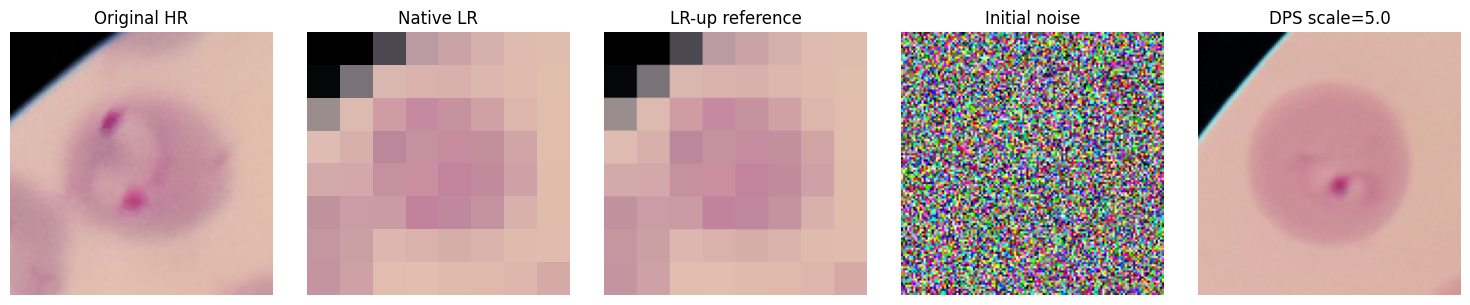

In [53]:
ncols = 5
fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
show_tensor(axes[0], x_hr, "Original HR")
show_tensor(axes[1], y_lr, "Native LR")
show_tensor(axes[2], lr_up_ref, "LR-up reference")
show_tensor(axes[3], z_init, "Initial noise")
show_tensor(axes[4], x_dps, f"DPS scale={GUIDANCE_SCALE}")
plt.tight_layout()

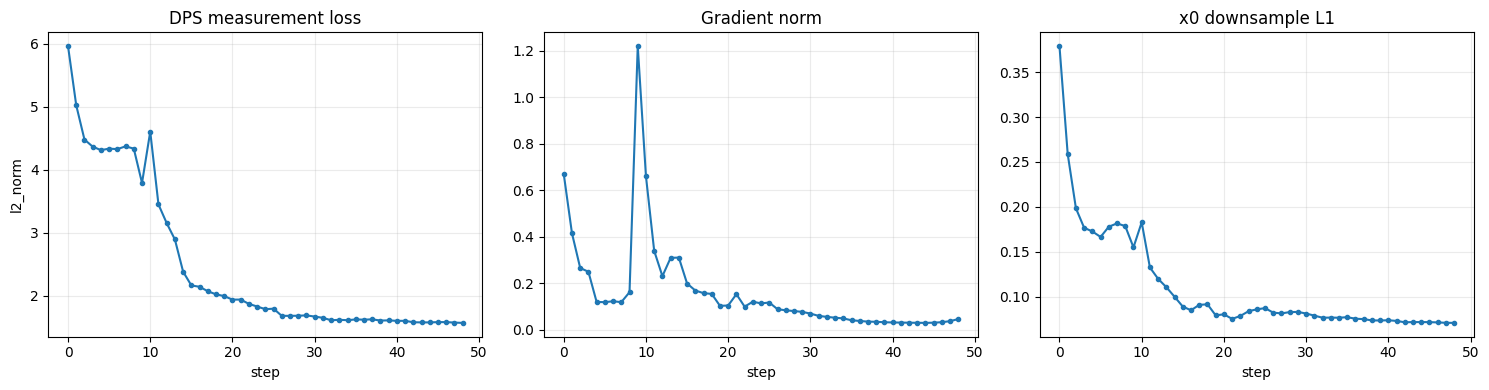

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(trajectory["step"], trajectory["measurement_loss"], marker="o", ms=3)
axes[0].set_title("DPS measurement loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel(LOSS_TYPE)
axes[0].grid(True, alpha=0.25)
axes[1].plot(trajectory["step"], trajectory["grad_norm"], marker="o", ms=3)
axes[1].set_title("Gradient norm")
axes[1].set_xlabel("step")
axes[1].grid(True, alpha=0.25)
axes[2].plot(trajectory["step"], trajectory["x0_downsample_l1"], marker="o", ms=3)
axes[2].set_title("x0 downsample L1")
axes[2].set_xlabel("step")
axes[2].grid(True, alpha=0.25)
plt.tight_layout()

## Guidance Scale Ablation

In [55]:
def evaluate_output(x, guidance_scale, seed):
    with torch.enable_grad():
        final_measurement_loss = measurement_loss(x, debug_batch, cfg, loss_type=LOSS_TYPE)
    return {
        "guidance_scale": float(guidance_scale),
        "seed": int(seed),
        "measurement_loss": scalar(final_measurement_loss),
        "downsample_l1": scalar(downsample_l1(x.detach(), y_lr, lr_size=lr_size, mode=DEGRADE_MODE).mean()),
        "rapsd_error": scalar(rapsd_error(x.detach(), x_hr).mean()),
    }


ablation_outputs = []
ablation_records = []
if RUN_GUIDANCE_SWEEP:
    for scale in GUIDANCE_SCALES:
        torch.manual_seed(SEED)
        z = torch.randn_like(x_hr)
        x_out, _, traj = dps_loop_debug(z, guidance_scale=float(scale), max_steps=MAX_DEBUG_STEPS)
        ablation_outputs.append((scale, x_out.detach()))
        record = evaluate_output(x_out, guidance_scale=scale, seed=SEED)
        record["last_debug_measurement_loss"] = (
            float(traj["measurement_loss"].dropna().iloc[-1]) if traj["measurement_loss"].notna().any() else float("nan")
        )
        record["last_grad_norm"] = float(traj["grad_norm"].iloc[-1]) if len(traj) else float("nan")
        ablation_records.append(record)
pd.DataFrame(ablation_records)

,guidance_scale,seed,measurement_loss,downsample_l1,rapsd_error,last_debug_measurement_loss,last_grad_norm
0,0.0,42,4.940987,0.215443,1.876961,NaN,0.000000
1,0.5,42,4.696699,0.196249,1.776535,4.698155,0.050141
2,1.0,42,4.461396,0.189503,1.760929,4.464585,0.051749
3,2.0,42,3.928413,0.172830,1.764028,3.934827,0.051495
4,5.0,42,1.551728,0.070146,0.444146,1.565320,0.045410
5,8.0,42,0.552228,0.026865,0.406965,0.575861,0.048586
6,10.0,42,0.329724,0.017639,0.383610,0.355623,0.045485


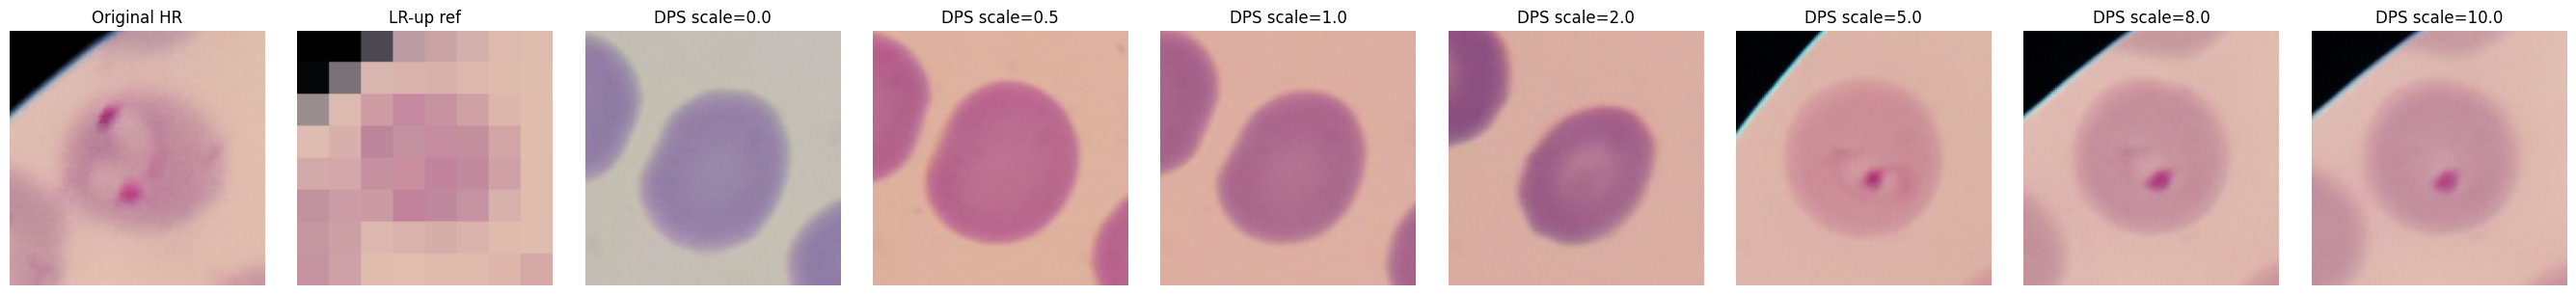

In [56]:
if ablation_outputs:
    fig, axes = plt.subplots(1, len(ablation_outputs) + 2, figsize=(3 * (len(ablation_outputs) + 2), 3))
    show_tensor(axes[0], x_hr, "Original HR")
    show_tensor(axes[1], lr_up_ref, "LR-up ref")
    for ax, (scale, x_out) in zip(axes[2:], ablation_outputs):
        show_tensor(ax, x_out, f"DPS scale={scale}")
    plt.tight_layout()
else:
    print("RUN_GUIDANCE_SWEEP=False")

## Optional Seed Sweep

In [57]:
seed_outputs = []
seed_records = []
if RUN_SEED_SWEEP:
    for seed in SEEDS:
        torch.manual_seed(int(seed))
        z = torch.randn_like(x_hr)
        x_out, _, _ = dps_loop_debug(z, guidance_scale=GUIDANCE_SCALE, max_steps=MAX_DEBUG_STEPS)
        seed_outputs.append((seed, x_out.detach()))
        seed_records.append(evaluate_output(x_out, guidance_scale=GUIDANCE_SCALE, seed=seed))
    fig, axes = plt.subplots(1, len(seed_outputs), figsize=(3 * len(seed_outputs), 3))
    if len(seed_outputs) == 1:
        axes = [axes]
    for ax, (seed, x_out) in zip(axes, seed_outputs):
        show_tensor(ax, x_out, f"seed={seed}")
    plt.tight_layout()
pd.DataFrame(seed_records)

""


## Spectral Diagnostics And Save Debug Outputs

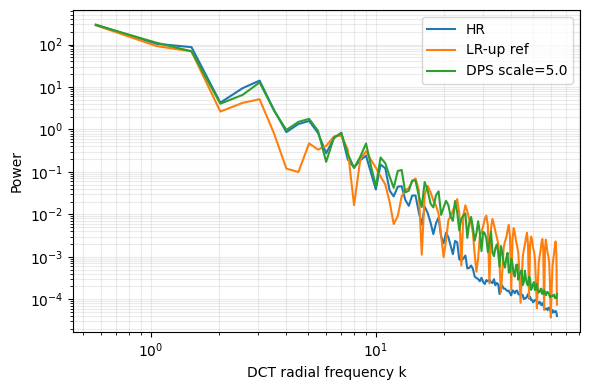

In [58]:
plt.figure(figsize=(6, 4))
for image, label in [(x_hr, "HR"), (lr_up_ref, "LR-up ref"), (x_dps, f"DPS scale={GUIDANCE_SCALE}")]:
    kk, pp = dct_rapsd_from_coefficients(dct2(image.float()))
    plt.loglog(kk.cpu(), pp[0].cpu(), label=label)
plt.xlabel("DCT radial frequency k")
plt.ylabel("Power")
plt.legend()
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()

In [ ]:
records = []
main_record = evaluate_output(x_dps, guidance_scale=GUIDANCE_SCALE, seed=SEED)
main_record.update(
    {
        "image_id": int(batch.get("sample_id", torch.tensor([sample_idx], device=device))[sample_idx].detach().cpu())
        if "sample_id" in batch
        else int(sample_idx)
    }
)
records.append(main_record)
records.extend(ablation_records)
records.extend(seed_records)

jsonl_path = out_dir / "per_image_dps_stats.jsonl"
with jsonl_path.open("w", encoding="utf-8") as handle:
    for record in records:
        handle.write(json.dumps(record) + "\n")

trajectory_path = out_dir / "dps_trajectory.csv"
trajectory.to_csv(trajectory_path, index=False)
summary = {
    "config_path": str(CONFIG_PATH),
    "checkpoint_path": str(checkpoint_path),
    "split": SPLIT,
    "sample_index": int(sample_idx),
    "degrade_mode": DEGRADE_MODE,
    "measurement_space": MEASUREMENT_SPACE,
    "base_sampler": BASE_SAMPLER,
    "guidance_scale": GUIDANCE_SCALE,
    "num_records": len(records),
    "main_record": main_record,
}
summary_path = out_dir / "dps_summary.json"
with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

pd.DataFrame(records), jsonl_path, trajectory_path, summary_path

(   guidance_scale  seed  measurement_loss  downsample_l1  rapsd_error  \
 0             5.0    42          1.551728       0.070146     0.444146   
 1             0.0    42          4.940987       0.215443     1.876961   
 2             0.5    42          4.696699       0.196249     1.776535   
 3             1.0    42          4.461396       0.189503     1.760929   
 4             2.0    42          3.928413       0.172830     1.764028   
 5             5.0    42          1.551728       0.070146     0.444146   
 6             8.0    42          0.552228       0.026865     0.406965   
 7            10.0    42          0.329724       0.017639     0.383610   
 
    image_id  last_debug_measurement_loss  last_grad_norm  
 0       5.0                          NaN             NaN  
 1       NaN                          NaN        0.000000  
 2       NaN                     4.698155        0.050141  
 3       NaN                     4.464585        0.051749  
 4       NaN                    

: 